### Importing Packages

In [55]:
import torch
import torch.nn as nn
import torchvision.utils as vutils
import torchvision.transforms as transforms
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import ignite
from ignite.engine import Engine, Events
import ignite.distributed as idist

### Configuring device to CUDA

In [92]:
device = torch.device('cuda' if torch.cuda.is_available() == True else 'cpu')

device(type='cuda')

### Setting up dataloaders

In [57]:
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.utils.data import DataLoader

# Resizing and tensorizing images for training purposes
xray_data = dataset.ImageFolder(root = 'data/train', 
                                     transform = transforms.Compose([
                                         transforms.Resize(64),
                                         transforms.CenterCrop(64),
                                         transforms.ToTensor(),
                                     ]))

# train-test split
train_size = int(.7 * len(xray_data))
test_size = len(xray_data) - train_size

train_set, test_set = torch.utils.data.random_split(xray_data, [train_size, test_size])
train_loader = idist.auto_dataloader(train_set, batch_size = 128, shuffle = True, drop_last = True)
test_loader = idist.auto_dataloader(test_set, batch_size = 128, shuffle = True, drop_last = True)

2025-05-17 06:15:40,553 ignite.distributed.auto.auto_dataloader INFO: Use data loader kwargs for dataset '<torch.utils.data.da': 
	{'batch_size': 128, 'shuffle': True, 'drop_last': True, 'pin_memory': True}
2025-05-17 06:15:40,554 ignite.distributed.auto.auto_dataloader INFO: Use data loader kwargs for dataset '<torch.utils.data.da': 
	{'batch_size': 128, 'shuffle': True, 'drop_last': True, 'pin_memory': True}


### Visualzing Training Images

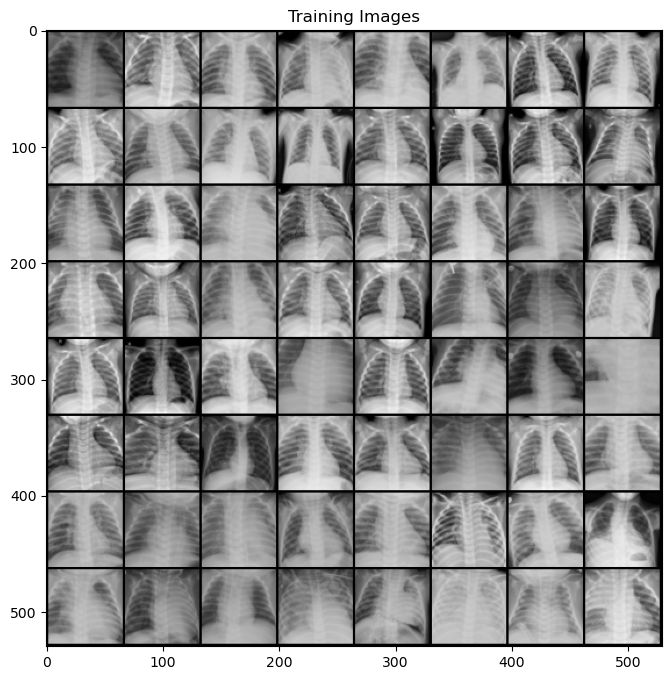

In [58]:
plt.figure(figsize = (8, 8))
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(next(iter(train_loader))[0][:64], padding = 2, normalize = True).cpu(), (1, 2, 0)))

### Defining the VAE model

### Initializing models

In [59]:
from model import VanillaVAE
model = idist.auto_model(VanillaVAE(),  device = idist.device())

### Initializing hyperparameters

In [60]:
from torch.optim import Adam
BCE_loss = nn.BCELoss()
def loss_fcn(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction = 'sum') # conditional probability term in loss function
    KLD = 0.5 * torch.sum(mean.pow(2) + log_var.exp() - (log_var + 1)) # KL divergence term in loss function

    return reproduction_loss + KLD

optimizer = idist.auto_optim(Adam(model.parameters(), lr = .001))

### Training VAE 

In [61]:
def train(engine, data):
    model.train()
    x = data[0].to(idist.device())

    if x.ndim == 2 and x.shape[1] == 3 * 64 * 64:
        x = x.view(-1, 3, 64, 64)

    optimizer.zero_grad()
    x_hat, mean, log_var = model(x)
    loss = loss_fcn(x, x_hat, mean, log_var)
    loss.backward()
    optimizer.step()

    return {
        "Loss": loss / x.size(0)
    }


trainer = Engine(train)

In [62]:
loss_epochs = []
@trainer.on(Events.EPOCH_COMPLETED)
def store_losses(engine):
    o = engine.state.output
    loss_epochs.append(o["Loss"])

### Calculating FID and Inception Score

Note: All code for computing the metrics involving the functions were taken from https://pytorch-ignite.ai/blog/gan-evaluation-with-fid-and-is/

In [63]:
from ignite.metrics import FID, InceptionScore

In [64]:
fid_metric = FID(device = idist.device())
is_metric = InceptionScore(device = idist.device(), output_transform = lambda x: x[0])

In [70]:
import PIL.Image as Image


def interpolate(batch):
    # this function reshapes the images for the metric calculations
    arr = []
    for img in batch:
        pil_img = transforms.ToPILImage()(img)
        resized_img = pil_img.resize((299,299), Image.BILINEAR)
        arr.append(transforms.ToTensor()(resized_img))
    return torch.stack(arr)


def evaluation_step(engine, batch):
    model.eval()
    with torch.no_grad():
        batch = batch[0].to(device)

        if batch.ndim == 2 and batch.shape[1] == 3 * 64 * 64:
            batch = batch.view(-1, 3, 64, 64)

        fake = model(batch)[0]

        fake = fake.view(-1, 3, 64, 64)
        batch = batch.view(-1, 3, 64, 64)

        fake = interpolate(fake)
        batch = interpolate(batch)
        return batch, fake


In [71]:
evaluator = Engine(evaluation_step)
fid_metric.attach(evaluator, "fid")
is_metric.attach(evaluator, "is")

In [72]:
fid_values = []
is_values = []


@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(engine):
    # this function prints the metrics after every epoch is completed
    evaluator.run(test_loader,max_epochs=1)
    metrics = evaluator.state.metrics
    fid_score = metrics['fid']
    is_score = metrics['is']
    fid_values.append(fid_score)
    is_values.append(is_score)
    print(f"Epoch [{engine.state.epoch}/5] Metric Scores")
    print(f"*   FID : {fid_score:4f}")
    print(f"*    IS : {is_score:4f}")


In [73]:
def training(*args):
    trainer.run(train_loader, max_epochs=20)

In [75]:
with idist.Parallel(backend='gloo') as parallel:
    parallel.run(training)

2025-05-17 06:18:04,493 ignite.distributed.launcher.Parallel INFO: Initialized processing group with backend: 'gloo'
2025-05-17 06:18:04,495 ignite.distributed.launcher.Parallel INFO: - Run '<function training at 0x7f9249d4f920>' in 1 processes


Epoch [2/5] Metric Scores
*   FID : 0.117976
*    IS : 1.973260
Epoch [2/5] Metric Scores
*   FID : 0.119515
*    IS : 1.977992
Epoch [3/5] Metric Scores
*   FID : 0.114209
*    IS : 1.977001
Epoch [3/5] Metric Scores
*   FID : 0.115112
*    IS : 1.975821
Epoch [4/5] Metric Scores
*   FID : 0.106671
*    IS : 1.977638
Epoch [4/5] Metric Scores
*   FID : 0.106917
*    IS : 1.979776
Epoch [5/5] Metric Scores
*   FID : 0.103818
*    IS : 1.975031
Epoch [5/5] Metric Scores
*   FID : 0.103826
*    IS : 1.975585
Epoch [6/5] Metric Scores
*   FID : 0.102012
*    IS : 1.972074
Epoch [6/5] Metric Scores
*   FID : 0.103947
*    IS : 1.975872
Epoch [7/5] Metric Scores
*   FID : 0.090076
*    IS : 1.981888
Epoch [7/5] Metric Scores
*   FID : 0.088177
*    IS : 1.968539
Epoch [8/5] Metric Scores
*   FID : 0.085980
*    IS : 1.977182
Epoch [8/5] Metric Scores
*   FID : 0.085887
*    IS : 1.976720
Epoch [9/5] Metric Scores
*   FID : 0.080700
*    IS : 1.976168
Epoch [9/5] Metric Scores
*   FID : 0.07

2025-05-17 07:42:51,476 ignite.distributed.launcher.Parallel INFO: End of run
2025-05-17 07:42:51,482 ignite.distributed.launcher.Parallel INFO: Finalized processing group with backend: 'gloo'


Epoch [20/5] Metric Scores
*   FID : 0.042859
*    IS : 1.979075


### Loss/Metric Curves

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


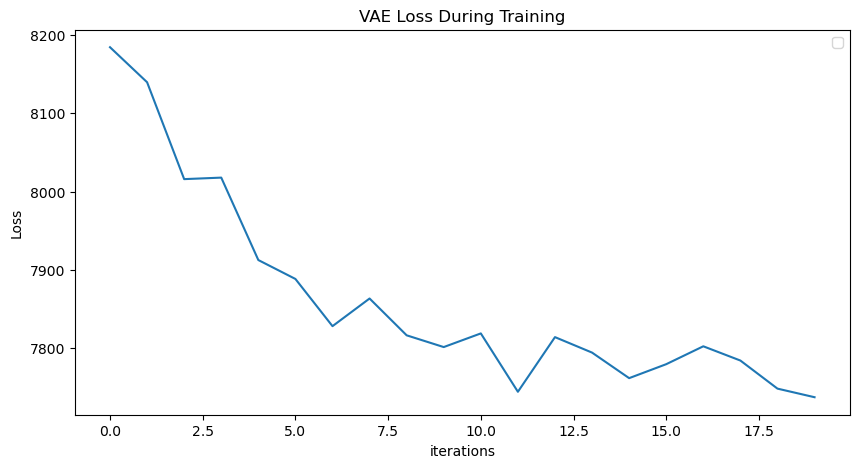

In [83]:
plt.figure(figsize=(10,5))
plt.title("VAE Loss During Training")
plt.plot(loss_epochs)
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()

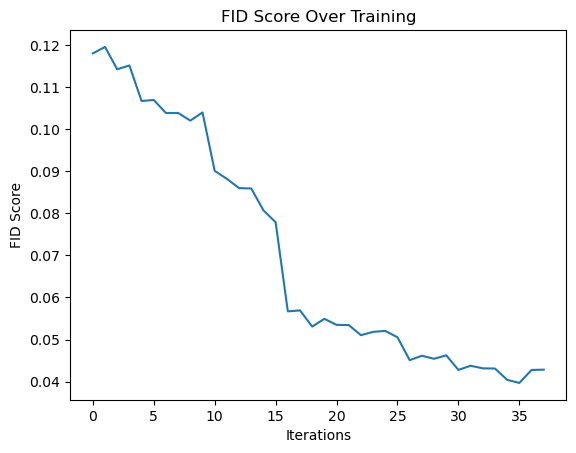

In [84]:
plt.title("FID Score Over Training")
plt.xlabel("Iterations")
plt.ylabel("FID Score")
plt.plot(fid_values, label = 'FID')

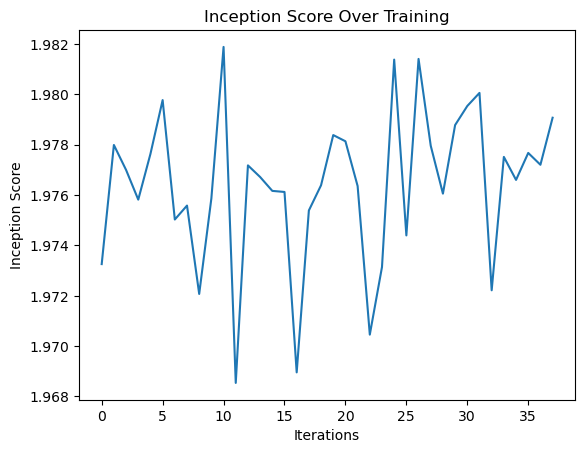

In [85]:
plt.title("Inception Score Over Training")
plt.xlabel("Iterations")
plt.ylabel("Inception Score")
plt.plot(is_values)

### Examples of Generated Images

In [88]:
model.eval()
for images, _ in test_loader:
    with torch.no_grad():
        for images, _ in train_loader:
            images = images.to(device)
    
            if images.ndim == 2 and images.shape[1] == 3 * 64 * 64:
                images = images.view(-1, 3, 64, 64)
    
            fake_images = model(images)[0]
            break
    
    fake_images = fake_images.view(-1, 3, 64, 64)


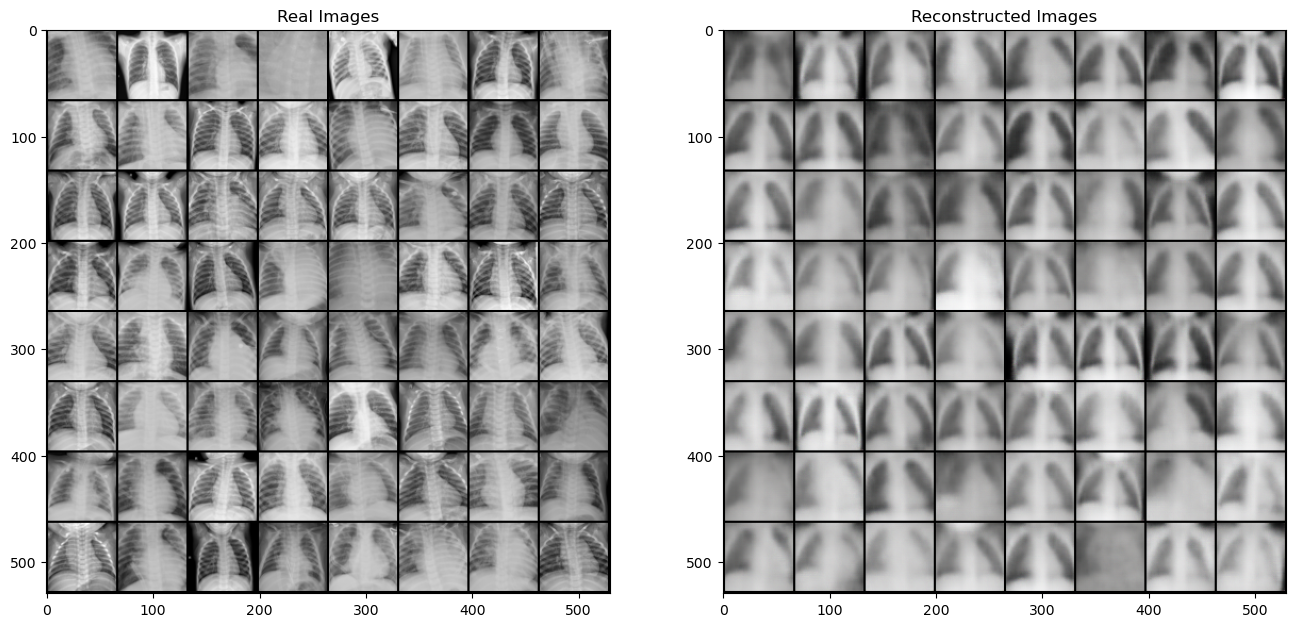

In [89]:
model.to(device = idist.device())
model.eval()
fig, axes = plt.subplots(1, 2, figsize = (16, 16))
axes[0].set_title("Real Images")
axes[0].imshow(np.transpose(vutils.make_grid(next(iter(test_loader))[0][:64], padding = 2, normalize = True).cpu(), (1, 2, 0)))
axes[1].set_title("Reconstructed Images")
axes[1].imshow(np.transpose(vutils.make_grid(fake_images[:64, :, :, :].cpu(), padding = 2, normalize = True), (1, 2, 0)))